# Chapter 3 — Multiple Assets: Correlation and Diversification

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion — execute the cells in order from top to bottom.

Chapters 1 and 2 lived inside a single asset. This chapter takes the **correlation risk** flavor that Chapter 2's framing named-but-deferred and breaks it into its own sub-flavors plus the statistical machinery for each. The arc deliberately mirrors Chapter 2: build the textbook tool first (Parts I and II), then show empirically how reality breaks it (Part III).

## What we mean by "correlation risk"

When we say "correlation risk" in this chapter, we don't mean a single thing. The concept has several flavors that don't reduce to each other:

1. **Pairwise correlation** — how tightly do two specific assets move together? (Ch3 Part I)
2. **Aggregation / portfolio risk** — what does combining *many* assets do to overall risk? (Ch3 Part II)
3. **Regime / crisis correlation** — correlations aren't constant. They spike toward 1 in crashes, so diversification weakens exactly when you need it. (Ch3 Part III)
4. **Hidden factor exposure** — seemingly distinct assets share underlying drivers (rates, oil, the broad market itself); a "diversified" portfolio may be a single bet in disguise. *Deferred — future factor-models chapter.*
5. **Tail dependence** — even if *average* correlation is low, two assets may always crash *together*. *Deferred — much later (with EVT / copulas).*

When the rest of this chapter says "correlation risk," read it as "the magnitude, aggregation, and regime dimensions of correlation risk" — not "everything anyone has ever called correlation risk." Chapter 2 used the same disclaimer pattern.

## 1. Setup and data refresh

Same library stack as Chapter 2 — no new dependencies. Multi-ticker download this time: an 8-asset basket spanning broad equities (SPY), bonds (TLT), gold (GLD), and five US sector ETFs (XLK tech, XLF financials, XLE energy, XLV healthcare, XLU utilities). Twenty-year window, log returns throughout, consistent with Chapter 2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print(f"numpy   {np.__version__}")
print(f"pandas  {pd.__version__}")
print(f"yf      {yf.__version__}")

numpy   2.4.4
pandas  3.0.2
yf      1.3.0


In [2]:
tickers = ["SPY", "TLT", "GLD", "XLK", "XLF", "XLE", "XLV", "XLU"]
data = yf.download(tickers, period="20y", progress=False)
prices = data["Close"][tickers]   # column order matches `tickers`
print(f"shape: {prices.shape}")
print(f"date range: {prices.index.min().date()} to {prices.index.max().date()}")
prices.head()

shape: (5032, 8)
date range: 2006-04-25 to 2026-04-24


Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU
Date,,,,,,,,
2006-04-25,90.108528,44.687496,62.779999,8.495028,17.986374,16.131062,21.877583,7.784664
2006-04-26,90.129272,44.613148,63.650002,8.525892,18.090151,15.875500,21.877583,7.707046
2006-04-27,90.564697,44.671558,62.959999,8.610762,18.374180,15.694939,21.757021,7.809705
2006-04-28,90.868828,44.703411,65.089996,8.429441,18.548965,15.872720,21.976852,7.842254
2006-05-01,90.129272,44.367474,65.160004,8.360006,18.259478,16.133848,21.785389,7.769638


Compute log returns for all eight assets in one shot. The result is a panel — rows are dates, columns are tickers.

In [3]:
log_returns = np.log(prices / prices.shift(1)).dropna()

summary = pd.DataFrame({
    "daily mean":      log_returns.mean(),
    "daily std":       log_returns.std(),
    "annualized vol":  log_returns.std() * np.sqrt(252),
})
summary

,daily mean,daily std,annualized vol
Ticker,,,
SPY,0.000411,0.012251,0.194473
TLT,0.000132,0.009391,0.149071
GLD,0.000384,0.011518,0.182847
XLK,0.000584,0.014445,0.229304
XLF,0.000209,0.018793,0.298336
XLE,0.000250,0.019052,0.302440
XLV,0.000375,0.010704,0.169925
XLU,0.000354,0.011901,0.188926


### The covariance matrix Σ

Chapter 2 §3.2 introduced **covariance** — the average product of two variables' deviations from their means — and noted "this will reappear as the central object of Chapter 3." Here it is. With *N* assets, the natural object isn't a single covariance number but the entire **covariance matrix** Σ:

> Σ<sub>ij</sub> = Cov(*r<sub>i</sub>*, *r<sub>j</sub>*)

This is a square *N* × *N* matrix where:
- The **diagonal** (Σ<sub>ii</sub> = Cov(*r<sub>i</sub>*, *r<sub>i</sub>*) = Var(*r<sub>i</sub>*)) is each asset's *variance* — the same per-asset numbers Chapter 2 worked with.
- The **off-diagonals** carry the new information: how each pair co-moves.

Σ is symmetric (Cov(*X*, *Y*) = Cov(*Y*, *X*)).

In [4]:
cov_matrix = log_returns.cov()
print("8x8 covariance matrix (daily, log returns):")
cov_matrix

8x8 covariance matrix (daily, log returns):


Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU
Ticker,,,,,,,,
SPY,0.000150,-0.000036,0.000008,0.000162,0.000194,0.000169,0.000106,0.000094
TLT,-0.000036,0.000088,0.000017,-0.000034,-0.000059,-0.000057,-0.000024,-0.000010
GLD,0.000008,0.000017,0.000133,0.000008,-0.000008,0.000033,0.000004,0.000017
XLK,0.000162,-0.000034,0.000008,0.000209,0.000186,0.000157,0.000105,0.000089
XLF,0.000194,-0.000059,-0.000008,0.000186,0.000353,0.000228,0.000128,0.000114
XLE,0.000169,-0.000057,0.000033,0.000157,0.000228,0.000363,0.000110,0.000114
XLV,0.000106,-0.000024,0.000004,0.000105,0.000128,0.000110,0.000115,0.000076
XLU,0.000094,-0.000010,0.000017,0.000089,0.000114,0.000114,0.000076,0.000142


## 2. Part I — Pairwise correlation (the textbook tool)

The numbers in the covariance matrix above are hard to read directly because they're tiny (daily-return variances are tiny) and they have units (squared returns). The conventional fix is to normalize them into **correlations**.

### 2.1 Pearson correlation — the unitless cousin of covariance

> *ρ<sub>XY</sub>* = Cov(*X*, *Y*) / (*σ<sub>X</sub> σ<sub>Y</sub>*)

where:
- Cov(*X*, *Y*) — the covariance between *X* and *Y* (Ch2 §3.2).
- *σ<sub>X</sub>*, *σ<sub>Y</sub>* — the standard deviations of *X* and *Y*.
- *ρ<sub>XY</sub>* — the **Pearson correlation coefficient**, bounded in [−1, +1].

Why divide? Covariance scales with the units of *X* and *Y* — a covariance computed on percent returns is different from one on basis-point returns, even though it's the *same data*. Dividing by *σ<sub>X</sub> σ<sub>Y</sub>* removes the units. The result is a unitless number with a fixed range, comparable across asset pairs.

<details>
<summary><b>The math, if you want it: why ρ is bounded in [−1, +1]</b></summary>

This is the **Cauchy–Schwarz inequality** in disguise. For any two random variables *X* and *Y*:

> |Cov(*X*, *Y*)| ≤ *σ<sub>X</sub> σ<sub>Y</sub>*

Proof sketch: define *Z* = *X*/σ<sub>X</sub> ± *Y*/σ<sub>Y</sub>. Var(*Z*) ≥ 0 because variance can't be negative. Expanding gives 2 ± 2 Cov(*X*, *Y*)/(σ<sub>X</sub> σ<sub>Y</sub>) ≥ 0, which rearranges to |Cov(*X*, *Y*)| ≤ σ<sub>X</sub> σ<sub>Y</sub>. Dividing through by σ<sub>X</sub> σ<sub>Y</sub> gives |ρ| ≤ 1.

The bounds are *attained* when *Y* is a perfect linear function of *X*: ρ = +1 when *Y* = *aX* + *b* with *a* > 0, ρ = −1 when *a* < 0, ρ = 0 when *X* and *Y* are linearly independent (though they may still be related nonlinearly — a famous correlation pitfall).

</details>

Pandas computes the whole correlation matrix for us in one call:

In [5]:
corr_matrix = log_returns.corr()
corr_matrix.round(3)

Ticker,SPY,TLT,GLD,XLK,XLF,XLE,XLV,XLU
Ticker,,,,,,,,
SPY,1.000,-0.309,0.059,0.915,0.842,0.725,0.805,0.647
TLT,-0.309,1.000,0.159,-0.252,-0.332,-0.320,-0.236,-0.093
GLD,0.059,0.159,1.000,0.049,-0.036,0.150,0.032,0.128
XLK,0.915,-0.252,0.049,1.000,0.684,0.569,0.681,0.516
XLF,0.842,-0.332,-0.036,0.684,1.000,0.637,0.637,0.511
XLE,0.725,-0.320,0.150,0.569,0.637,1.000,0.541,0.504
XLV,0.805,-0.236,0.032,0.681,0.637,0.541,1.000,0.596
XLU,0.647,-0.093,0.128,0.516,0.511,0.504,0.596,1.000


Read this matrix:
- **Diagonal is 1.0** — every asset is perfectly correlated with itself.
- **Sector ETFs cluster high** with SPY (0.65–0.92) and with each other (0.5–0.7). They're all flavors of US equity risk.
- **TLT row/column shows moderately *negative* correlations** with the equity assets (around −0.25 to −0.33). Bonds were a real hedge through most of the 20-year window — when stocks fell, Treasuries rallied. (We'll see in Part III that this isn't a constant; the long-run average masks a regime shift around 2020.)
- **GLD row/column** has uniformly low correlations with everything else — neither equity nor bonds explain its movements. Closer to genuinely independent.

The most strongly *negative* off-diagonal is the TLT/equity block; the most strongly *positive* is SPY's correlation with the broad sector ETFs.

### 2.2 What different correlations look like

Three scatter plots of daily log returns, with very different correlations.

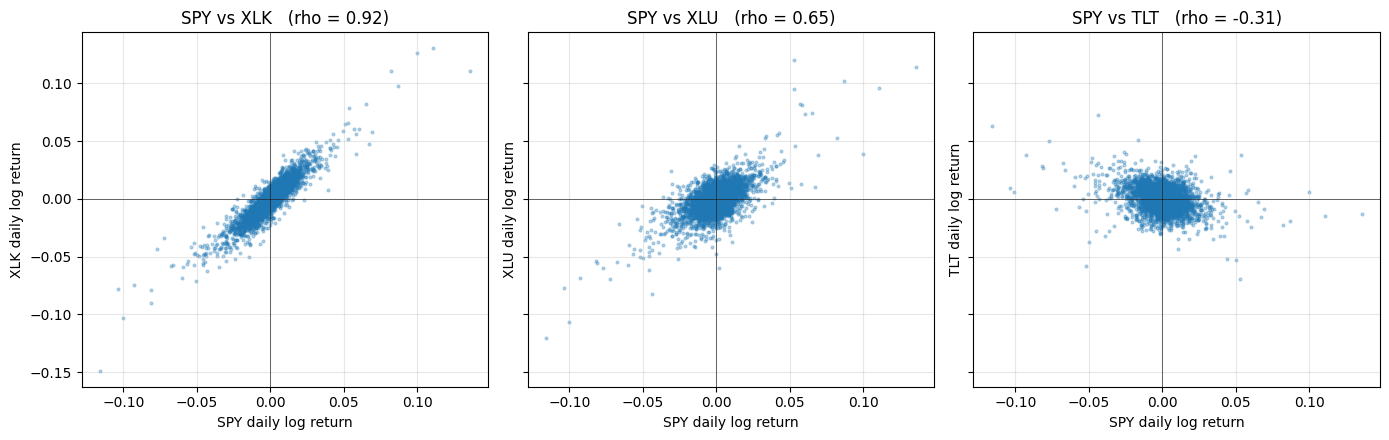

In [6]:
pairs = [("SPY", "XLK"), ("SPY", "XLU"), ("SPY", "TLT")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)

for ax, (a, b) in zip(axes, pairs):
    rho = corr_matrix.loc[a, b]
    ax.scatter(log_returns[a], log_returns[b], s=4, alpha=0.3)
    ax.axhline(0, color="black", lw=0.4)
    ax.axvline(0, color="black", lw=0.4)
    ax.set_xlabel(f"{a} daily log return")
    ax.set_ylabel(f"{b} daily log return")
    ax.set_title(f"{a} vs {b}   (rho = {rho:.2f})")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Same axes scale across all three plots, so the visual comparison is honest:

- **SPY vs XLK** (ρ ≈ +0.92) — a tight diagonal cloud. These are nearly the same asset; XLK is large-cap tech, which dominates SPY's market-cap-weighted index. Knowing one move tells you almost everything about the other.
- **SPY vs XLU** (ρ ≈ +0.65) — clearly correlated, but visibly looser. Utilities are equity but defensive — they move with the market on most days, but with less amplitude.
- **SPY vs TLT** (ρ ≈ −0.31) — slight *downward* tilt in the cloud. The negative correlation is moderate, not perfect; many days look independent, but on average when SPY is up TLT is down a bit, and vice-versa. Plenty of stocks-down-bonds-up days populating the upper-left quadrant — that's the bond hedge in pictures.

The "correlation captures *linear* co-movement" framing is literal: ρ ≈ +1 means a positive-slope diagonal, ρ ≈ −1 means a negative-slope diagonal, ρ ≈ 0 means no preferred line.

### 2.3 What this means with $100k

The point of correlation isn't the ρ number — it's what the number says about a real position. Imagine you hold $100k of SPY and want to "diversify" by adding another $100k of something else. Three candidate add-ons (assuming for simplicity all three have the same vol as SPY — TLT's actual lower vol would help even further):

- **Add $100k of XLK** (ρ ≈ +0.92 with SPY). XLK and SPY barely behave like distinct assets. The combined $200k position has roughly **1.96×** the dollar risk of the original $100k SPY — almost no diversification benefit. You doubled exposure, not safety.
- **Add $100k of XLU** (ρ ≈ +0.65). Better. Some of XLU's variance is independent of SPY's, so the combined position has roughly **1.82×** the original risk — meaningfully less than 2×.
- **Add $100k of TLT** (ρ ≈ −0.31). Negative correlation is *better* than uncorrelated for risk reduction — the cross-term in the variance formula now *subtracts* from total variance. The combined $200k position has only **1.18×** the original risk. The cross-asset "60/40-style" play is the cleanest example of correlation working in your favor.

(The 1.96×, 1.82×, 1.18× factors come from the two-asset variance formula in §3.1, which we'll prove next. They use 50/50 weights and the simplifying assumption of equal vols.)

## 3. Part II — Aggregation: portfolio variance and the diversification math

Pairs are the simplest case. Real portfolios have many positions. Going from "two correlations" to "many correlations" is where the matrix Σ from §1 starts paying for itself.

### 3.1 Two-asset portfolio variance

Hold *w<sub>X</sub>* fraction of asset X and *w<sub>Y</sub>* = 1 − *w<sub>X</sub>* of asset Y. The portfolio's daily return is *r<sub>p</sub>* = *w<sub>X</sub> r<sub>X</sub>* + *w<sub>Y</sub> r<sub>Y</sub>*. Its variance is:

> *σ<sub>p</sub>²* = *w<sub>X</sub>² σ<sub>X</sub>²* + *w<sub>Y</sub>² σ<sub>Y</sub>²* + 2 *w<sub>X</sub> w<sub>Y</sub> σ<sub>X</sub> σ<sub>Y</sub> ρ*

where:
- *w<sub>X</sub>*, *w<sub>Y</sub>* — the **portfolio weights** (must sum to 1 for a fully-invested long-only portfolio).
- *σ<sub>X</sub>*, *σ<sub>Y</sub>* — individual asset standard deviations.
- *ρ* — the pairwise correlation between *X* and *Y*.
- *σ<sub>p</sub>²* — the variance of the portfolio's return.

Three terms: the two **own-variance** terms (each weighted by *w²*) and the **cross-term** (the diversification engine). When ρ < 1, the cross-term shrinks the total variance below the weighted average of individual variances. When ρ = 1, no diversification — *σ<sub>p</sub>* is the weighted average of *σ<sub>X</sub>* and *σ<sub>Y</sub>*. When ρ = −1, perfect hedging is possible — there exist weights making *σ<sub>p</sub>* = 0.

<details>
<summary><b>The math, if you want it: deriving the two-asset variance</b></summary>

Var(*aX* + *bY*) = *a²* Var(*X*) + *b²* Var(*Y*) + 2*ab* Cov(*X*, *Y*).

Plug in *a* = *w<sub>X</sub>*, *b* = *w<sub>Y</sub>*, Var(*X*) = *σ<sub>X</sub>²*, Cov(*X*, *Y*) = *ρ σ<sub>X</sub> σ<sub>Y</sub>* (rearranged from the correlation definition):

*σ<sub>p</sub>²* = *w<sub>X</sub>² σ<sub>X</sub>²* + *w<sub>Y</sub>² σ<sub>Y</sub>²* + 2 *w<sub>X</sub> w<sub>Y</sub> σ<sub>X</sub> σ<sub>Y</sub> ρ*

The variance-of-a-sum identity itself comes from expanding E[((*aX* + *bY*) − E[*aX* + *bY*])²]: the cross-term you get is 2*ab E*[(*X* − *μ<sub>X</sub>*)(*Y* − *μ<sub>Y</sub>*)] = 2*ab* Cov(*X*, *Y*) — exactly the *E*[·] machinery introduced in Ch2 §2.2 and used heavily in Ch2 §3.2.

</details>

Compute concrete numbers for a 50/50 SPY/TLT portfolio:

In [7]:
sigma_spy = log_returns["SPY"].std()
sigma_tlt = log_returns["TLT"].std()
rho       = corr_matrix.loc["SPY", "TLT"]
w_x = w_y = 0.5

sigma_p_squared = (
    w_x**2 * sigma_spy**2
    + w_y**2 * sigma_tlt**2
    + 2 * w_x * w_y * sigma_spy * sigma_tlt * rho
)
sigma_p = np.sqrt(sigma_p_squared)

ann = lambda s: s * np.sqrt(252)

print(f"SPY annualized vol:        {ann(sigma_spy):.2%}")
print(f"TLT annualized vol:        {ann(sigma_tlt):.2%}")
print(f"SPY/TLT correlation:       {rho:.3f}")
print(f"50/50 portfolio vol:       {ann(sigma_p):.2%}")
print(f"Weighted-average of sigma: {ann(0.5 * sigma_spy + 0.5 * sigma_tlt):.2%}")
print(f"Diversification benefit:   {ann(0.5 * sigma_spy + 0.5 * sigma_tlt) - ann(sigma_p):.2%}")

SPY annualized vol:        19.45%
TLT annualized vol:        14.91%
SPY/TLT correlation:       -0.309
50/50 portfolio vol:       10.26%
Weighted-average of sigma: 17.18%
Diversification benefit:   6.91%


The 50/50 portfolio's vol is meaningfully *below* the weighted average of the individual vols. That gap is the **diversification benefit** — the cross-term in the formula doing its work.

### 3.2 The correlation matrix as a heatmap

The 8×8 correlation matrix from §2.1 has structure that's easier to see visually than as a table of numbers.

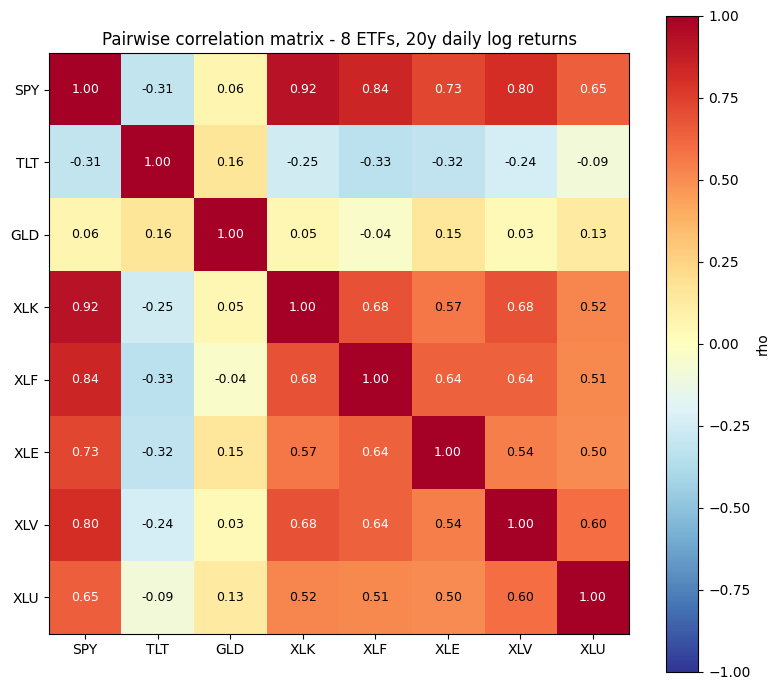

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix.values, cmap="RdYlBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)

# Annotate each cell with its correlation value.
for i in range(len(tickers)):
    for j in range(len(tickers)):
        v = corr_matrix.iloc[i, j]
        color = "white" if abs(v) > 0.6 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=9)

ax.set_title("Pairwise correlation matrix - 8 ETFs, 20y daily log returns")
plt.colorbar(im, ax=ax, label="rho")
plt.tight_layout()
plt.show()

Three blocks visible:

- **Sector ETFs (XLK / XLF / XLE / XLV / XLU) form a high-correlation cluster** in the bottom-right. They're all US equity, and the correlations among them sit in a 0.5–0.7 range. The whole block has high correlation with SPY too (top row / left column for the sectors).
- **TLT row/column** is the visual outlier — clearly *blue* (negative). Its long-run correlation with all the equity assets sits around −0.25 to −0.33. That's the bond-hedge story baked into the average.
- **GLD row/column** is uniformly pale — correlations near zero with everything else, neither equity nor bonds explain its movements.

This is the input we'll feed into the portfolio-variance machinery next.

### 3.3 The diversification math empirically

The two-asset formula generalizes to *N* assets — but rather than write the formula yet, let's just *compute* portfolio vol as we add tickers one at a time, in a deliberate order designed to make the lesson visible:

`XLK → +XLF → +XLE → +XLV → +XLU → +TLT → +GLD`

Start with one sector. Add four more sectors (correlated names). Then add TLT (cross-asset, decorrelated). Then add GLD. Equal weights at each step. Plot the resulting annualized volatility.

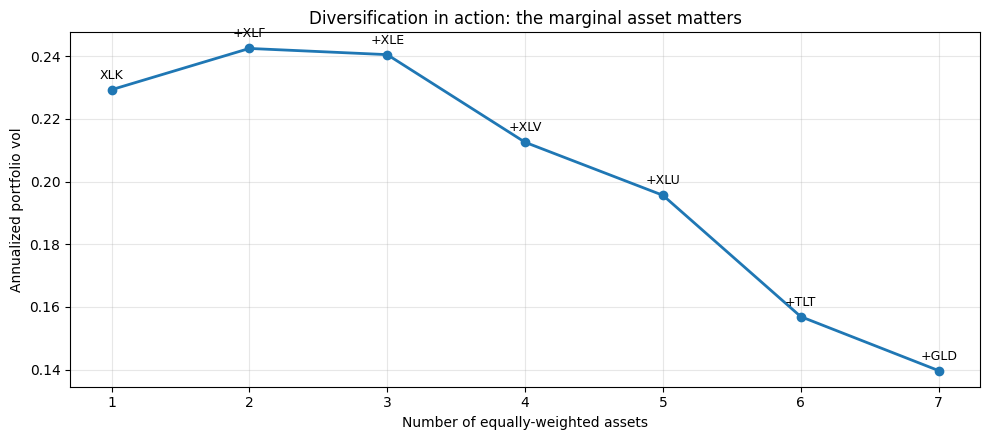

In [9]:
order = ["XLK", "XLF", "XLE", "XLV", "XLU", "TLT", "GLD"]
ann_vols = []

for k in range(1, len(order) + 1):
    basket = order[:k]
    w = np.ones(k) / k
    sub_cov = log_returns[basket].cov().values
    var_p = w @ sub_cov @ w
    ann_vols.append(np.sqrt(var_p) * np.sqrt(252))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(range(1, len(order) + 1), ann_vols, marker="o", lw=2)

# Annotate which ticker was just added.
for k, t in enumerate(order, start=1):
    ax.annotate(f"+{t}" if k > 1 else t,
                xy=(k, ann_vols[k-1]), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=9)

ax.set_xlabel("Number of equally-weighted assets")
ax.set_ylabel("Annualized portfolio vol")
ax.set_title("Diversification in action: the marginal asset matters")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Read the curve from left to right:

- **N = 1 (just XLK)** — high vol, ~25%+ annualized. A single sector is a concentrated bet.
- **N = 2 to 5 (adding sector ETFs)** — vol drops, but each step is a modest improvement. Adding correlated names doesn't help much. By the time all five sectors are in, you've roughly recovered SPY's ~19% vol.
- **N = 6 (adding TLT)** — sharp drop. TLT is uncorrelated-to-negative with the equity basket, so the cross-term in the variance formula works in your favor for the first time.
- **N = 7 (adding GLD)** — small further drop. Most of the diversification benefit was already captured by the cross-asset move at N = 6.

**The marginal benefit of one more asset depends entirely on its correlation with what you already hold.** Adding correlated names dilutes the basket toward "the sector average"; adding decorrelated names actually reduces risk.

Two limit results worth knowing:

> **√N rule** — *σ<sub>p</sub>* = *σ* / √*N* if all *N* assets share volatility *σ* and are *uncorrelated*. The most-diversification-possible result.
>
> **Diversification floor** — if all pairwise correlations equal a common value *ρ*, then *σ<sub>p</sub>²* / *σ²* → *ρ* as *N* → ∞. You can't diversify away the *shared* portion; only the idiosyncratic portion goes to zero.

<details>
<summary><b>The math, if you want it: the diversification-floor derivation</b></summary>

Equal-weighted *N*-asset portfolio: *w<sub>i</sub>* = 1/*N* for all *i*. Assume each asset has variance *σ²* and every pair has correlation *ρ* (so Σ<sub>ij</sub> = *σ²* for *i* = *j*, and *ρσ²* otherwise).

*σ<sub>p</sub>²* = (1/*N²*) · [*N* diagonal terms · *σ²* + *N*(*N* − 1) off-diagonal terms · *ρσ²*]

Simplifying: *σ<sub>p</sub>²* / *σ²* = 1/*N* + (*N* − 1)/*N* · *ρ* = *ρ* + (1 − *ρ*)/*N*.

As *N* → ∞, the 1/*N* term vanishes and the ratio approaches *ρ*. The portion (1 − *ρ*) is *idiosyncratic* — diversifiable. The portion *ρ* is *systematic* — irreducible no matter how many assets you add.

This decomposition is the mathematical seed of CAPM and factor models. We'll meet those in a later chapter.

</details>

### 3.4 The matrix form

The two-asset formula *σ<sub>p</sub>²* = *w<sub>X</sub>² σ<sub>X</sub>²* + *w<sub>Y</sub>² σ<sub>Y</sub>²* + 2 *w<sub>X</sub> w<sub>Y</sub> σ<sub>X</sub> σ<sub>Y</sub> ρ* gets unwieldy fast. The general *N*-asset version is one line of linear algebra:

> *σ<sub>p</sub>²* = **w**ᵀ **Σ** **w**

where:
- **w** — the weight vector (length *N*; sums to 1 for a fully-invested portfolio).
- **Σ** — the *N* × *N* covariance matrix (which we've been working with).
- **w**ᵀ — the transpose of **w** (a row vector).
- **w**ᵀ **Σ** **w** — a scalar (a 1×1 matrix).

This is the formula we used in §3.3's code (look back: `var_p = w @ sub_cov @ w`). It's the building block of essentially all modern portfolio theory.

<details>
<summary><b>The math, if you want it: the matrix-form derivation</b></summary>

The portfolio return is a weighted sum: *r<sub>p</sub>* = Σ<sub>i</sub> *w<sub>i</sub> r<sub>i</sub>*. Its variance is:

Var(*r<sub>p</sub>*) = Var(Σ<sub>i</sub> *w<sub>i</sub> r<sub>i</sub>*) = Σ<sub>i</sub> Σ<sub>j</sub> *w<sub>i</sub> w<sub>j</sub>* Cov(*r<sub>i</sub>*, *r<sub>j</sub>*) = Σ<sub>i</sub> Σ<sub>j</sub> *w<sub>i</sub> w<sub>j</sub>* Σ<sub>ij</sub>

The double sum Σ<sub>i</sub> Σ<sub>j</sub> *w<sub>i</sub> w<sub>j</sub>* Σ<sub>ij</sub> is the entry-by-entry product of the outer product **ww**ᵀ with **Σ**, summed across all entries — which is exactly what **w**ᵀ **Σ** **w** computes in matrix notation.

The two-asset formula falls out as the *N* = 2 case: write out **w**ᵀ **Σ** **w** with **w** = [*w<sub>X</sub>*, *w<sub>Y</sub>*] and **Σ** = [[*σ<sub>X</sub>²*, *ρσ<sub>X</sub>σ<sub>Y</sub>*], [*ρσ<sub>X</sub>σ<sub>Y</sub>*, *σ<sub>Y</sub>²*]] and you recover the long-form formula exactly.

</details>

### 3.5 What this means with $100k — portfolio comparisons

Several portfolios you might actually consider, all $100k starting:

In [10]:
def portfolio_vol(weights, returns):
    cov = returns.cov().values
    w = np.array(weights)
    return np.sqrt(w @ cov @ w) * np.sqrt(252)

portfolios = {
    "All SPY (concentrated)":            (["SPY"], [1.0]),
    "All XLK (single sector)":           (["XLK"], [1.0]),
    "Equal-weight 5 sectors":            (["XLK","XLF","XLE","XLV","XLU"], [0.2]*5),
    "60/40 SPY/TLT":                     (["SPY","TLT"], [0.6, 0.4]),
    "Equal-weight all 8":                (tickers, [1/8]*8),
}

rows = []
for name, (basket, weights) in portfolios.items():
    v = portfolio_vol(weights, log_returns[basket])
    rows.append({
        "portfolio": name,
        "annualized vol": f"{v:.2%}",
        "typical-year swing on $100k": f"${100_000 * v:,.0f}",
    })

pd.DataFrame(rows)

,portfolio,annualized vol,typical-year swing on $100k
0,All SPY (concentrated),19.45%,"$19,447"
1,All XLK (single sector),22.93%,"$22,930"
2,Equal-weight 5 sectors,19.56%,"$19,561"
3,60/40 SPY/TLT,11.34%,"$11,345"
4,Equal-weight all 8,14.50%,"$14,498"


Read the right column. The "typical-year swing" is one annualized standard deviation in dollar terms — a rough sense of how much $100k is bouncing around in a normal year (no fat tails or clustering yet — that's still Chapter 2's lesson).

Two things worth pointing out:

1. **60/40 SPY/TLT is the *lowest*-vol portfolio in the table** — about $11k typical-year swing on $100k, vs $19k for all-SPY. The negative SPY/TLT correlation does the work. That's the textbook "balanced portfolio" earning its reputation.
2. **Equal-weight all 8 has *higher* vol than 60/40** ($14.5k vs $11.3k) — even though it has more assets. The reason: 5/8 of the basket is concentrated in high-vol US equity sectors (XLF and XLE both run ~30% vol). Naive equal-weighting *over-allocates* to the volatile names. Better weighting schemes (risk parity, mean-variance optimization) attempt to fix this — deferred to a later chapter.

Real portfolio construction is a balance between *return* (which generally favors equity-heavy) and *risk* (which generally favors diversification across asset classes — *and* thoughtful weighting). We'll formalize the return-vs-risk tradeoff with the **Sharpe ratio** in Chapter 4.

## 4. Part III — Regime / crisis correlation (the empirical wrinkle)

So far the chapter has used a **single** correlation number per pair — the long-run average over 20 years. Same shape of error as Ch1 making for Ch2: real correlations vary over time, and the variation has a particular character. They're not just noisy; they **cluster regime-by-regime**, and they **rise during crashes**.

### 4.1 Rolling correlation — the bond hedge unhedged itself

Compute SPY/TLT correlation in a 60-day rolling window through history. Same window length as Ch2's rolling vol, for the same noise/lag balance reason.

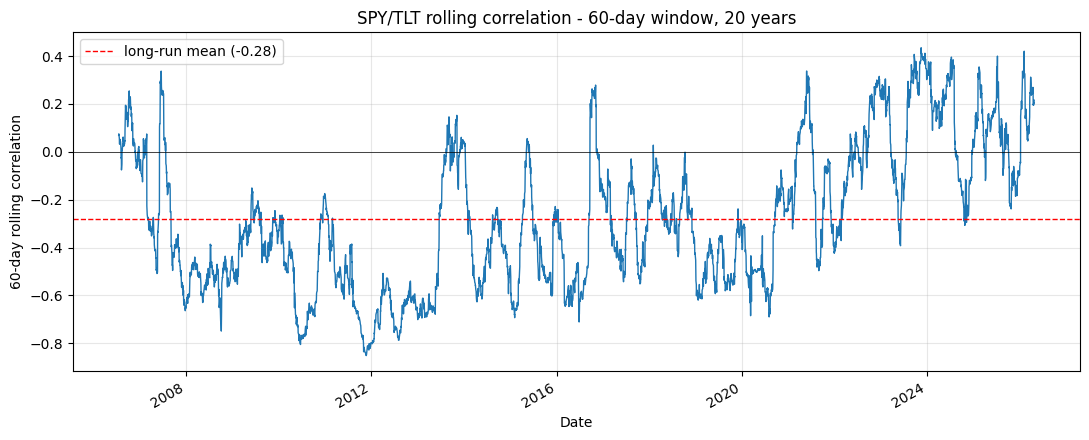

In [11]:
rolling_corr = log_returns["SPY"].rolling(60).corr(log_returns["TLT"])

fig, ax = plt.subplots(figsize=(11, 4.5))
rolling_corr.plot(ax=ax, lw=1)
ax.axhline(0, color="black", lw=0.5)
ax.axhline(rolling_corr.mean(), color="red", ls="--", lw=1,
           label=f"long-run mean ({rolling_corr.mean():.2f})")
ax.set_ylabel("60-day rolling correlation")
ax.set_xlabel("Date")
ax.set_title("SPY/TLT rolling correlation - 60-day window, 20 years")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

The plot tells a story very different from the static "ρ ≈ 0" we computed in Part I:

- **2007–2019** — sustained negative correlation. TLT genuinely *hedged* SPY: when stocks fell, Treasuries rallied. This is the regime that built the reputation of the "60/40 portfolio."
- **March 2020** — a brief sharp positive spike. During the COVID liquidity crisis everything sold off together for a few weeks (forced deleveraging — even safe assets get sold when investors need cash).
- **2022 onward** — sustained positive correlation. Both stocks and bonds fell together as rates rose; the inflation/rate-driven selloff hit duration assets and equities simultaneously.

**The "bond hedge" that worked for 15 years stopped working — and the regime change happened in months, not years.** The flat-line in the static analysis is an *average over genuinely different worlds*.

### 4.2 Conditional correlation — what happens on bad days?

A static correlation answers "on a typical day, do these move together?" A more interesting question for risk management: "*on the worst days*, do these move together?" Compute correlations conditional on the bottom 5% of SPY days — about 250 days in 20 years, the conventional VaR-territory threshold.

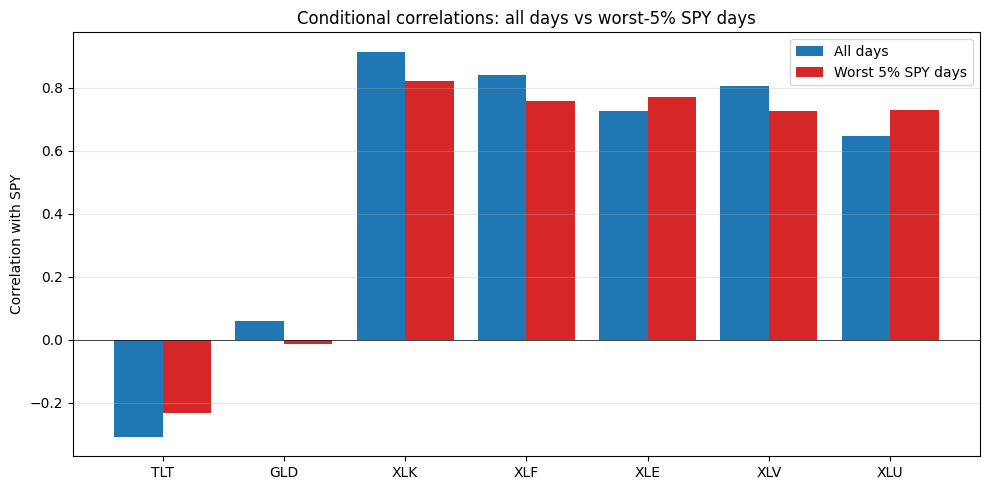

,asset,rho all days,rho worst-5% SPY days
0,TLT,-0.309,-0.234
1,GLD,0.059,-0.013
2,XLK,0.915,0.821
3,XLF,0.842,0.758
4,XLE,0.725,0.771
5,XLV,0.805,0.727
6,XLU,0.647,0.729


In [12]:
worst_5pct_threshold = log_returns["SPY"].quantile(0.05)
worst_days = log_returns["SPY"] <= worst_5pct_threshold

others = [t for t in tickers if t != "SPY"]
rows = []
for t in others:
    rho_all   = log_returns["SPY"].corr(log_returns[t])
    rho_worst = log_returns.loc[worst_days, "SPY"].corr(log_returns.loc[worst_days, t])
    rows.append({"asset": t, "rho all days": rho_all, "rho worst-5% SPY days": rho_worst})

cond = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cond))
width = 0.4
ax.bar(x - width/2, cond["rho all days"],          width, label="All days",          color="tab:blue")
ax.bar(x + width/2, cond["rho worst-5% SPY days"], width, label="Worst 5% SPY days", color="tab:red")
ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cond["asset"])
ax.set_ylabel("Correlation with SPY")
ax.set_title("Conditional correlations: all days vs worst-5% SPY days")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()
cond.round(3)

The picture is more nuanced than a clean "everything correlates in stress":

- **TLT** (the bond hedge): all-days ρ = −0.31, worst-5%-days ρ = −0.23. Still negative but **less so** — TLT's diversification power *weakens* exactly when SPY is in pain. This is the headline finding for the bond-hedge story.
- **GLD**: all-days ρ ≈ +0.06, worst-5%-days ρ ≈ −0.01. Roughly unchanged — gold is genuinely close to independent.
- **Sector ETFs (XLU, XLE)** show the textbook lift — already-positive correlations rise further on bad days.
- **High-correlation sectors (XLK, XLF, XLV)** *appear* to drop in conditional correlation. This is largely a **statistical artifact**: conditioning on the bottom 5% of SPY truncates SPY's variance, which mechanically shrinks any Pearson correlation involving it. The economic content is small.

**The cleaner picture lives in §4.3's heatmap diptych.** A side-by-side comparison of an entire calm-window correlation matrix vs an entire crisis-window correlation matrix avoids the truncation artifact and shows the regime shift in full color.

### 4.3 Calm vs crisis — the heatmap diptych

A **diptych** is just a two-panel side-by-side image (the word comes from art history — two hinged painted panels). Here we put two correlation heatmaps next to each other:

- **Calm regime:** all of 2017 (the lowest-vol full year in our window).
- **Crisis regime:** March–June 2020 (the COVID drawdown and aftermath).

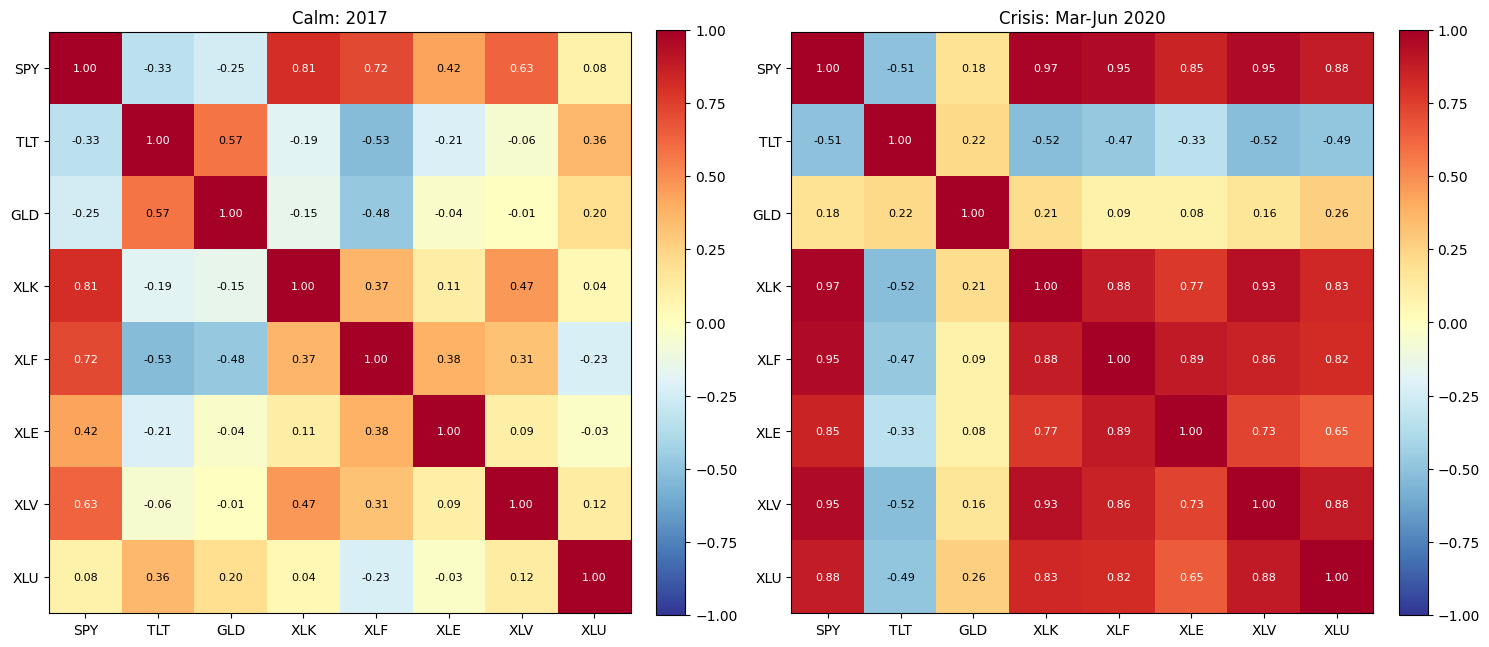

In [13]:
calm   = log_returns.loc["2017-01-01":"2017-12-31"]
crisis = log_returns.loc["2020-03-01":"2020-06-30"]

corr_calm   = calm.corr()
corr_crisis = crisis.corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, mat, title in [
    (axes[0], corr_calm,   "Calm: 2017"),
    (axes[1], corr_crisis, "Crisis: Mar-Jun 2020"),
]:
    im = ax.imshow(mat.values, cmap="RdYlBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(tickers)))
    ax.set_yticks(range(len(tickers)))
    ax.set_xticklabels(tickers)
    ax.set_yticklabels(tickers)
    for i in range(len(tickers)):
        for j in range(len(tickers)):
            v = mat.iloc[i, j]
            color = "white" if abs(v) > 0.6 else "black"
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Calm 2017 has structure: sector ETFs cluster, TLT is independent, GLD is independent. The matrix has *information* in it.

Crisis 2020 is uniformly red. Almost every cell sits in the 0.6–0.95 range. The structure has collapsed; everything is one position. **In a panic, all bets become a single bet.**

This is the same finding as §4.2's bar chart, told as a picture rather than a number. It's also the formal version of the "diversification fails when needed" intuition that's central to professional risk management.

### 4.4 What this means

Real correlation isn't a number — it's a *time-series of matrices*, each one capturing the regime of its window. The single ρ values from Parts I and II are useful summaries the way a single annualized vol is useful in Ch1: they tell you the long-run average. They don't tell you what happens on the worst day.

Two specific deferred topics, named here:

- **DCC-GARCH** (Dynamic Conditional Correlation) — formal time-series model of how correlations evolve. Same flavor as Ch2's GARCH (which models time-varying volatility), now applied to correlations. Future chapter.
- **Tail dependence and copulas** — formal models of the "everything correlates in tails" phenomenon. Much later in the curriculum (alongside EVT).

Neither is required for the practical portfolio reasoning we've done in this chapter. Both exist for readers who want the formal modeling tools.

## 5. What we just learned (recap by concept-flavor)

We named five flavors of correlation risk in the opening. Here's what we found, organized by flavor.

### Pairwise correlation
- Pearson correlation (*ρ*) is normalized covariance, bounded in [−1, +1], unitless and comparable across pairs.
- The same correlation number can mean *very* different things visually — sector ETFs at ρ ≈ +0.9 are nearly the same asset; SPY/TLT at ρ ≈ −0.31 shows a moderate negative tilt that's almost entirely the bond-hedge effect.
- The number doesn't capture *time* — that's Part III's job.

### Aggregation / portfolio risk
- Two-asset portfolio variance has a cross-term: 2 *w<sub>X</sub> w<sub>Y</sub> σ<sub>X</sub> σ<sub>Y</sub> ρ*. When ρ < 1 it shrinks total variance; when ρ < 0 it shrinks variance further still (the cross-term goes negative).
- The general formula is *σ<sub>p</sub>²* = **w**ᵀ **Σ** **w** — one matrix expression for any portfolio size.
- The marginal benefit of one more asset depends entirely on its correlation with what you already hold. Adding correlated names dilutes; adding decorrelated or negatively-correlated names actually reduces risk.
- More assets ≠ less risk. Equal-weight 8 had *higher* vol than 60/40 because the equal-weight scheme over-allocated to high-vol sector ETFs. Smart weighting matters.
- There's a floor: when every pair shares correlation *ρ*, no number of assets can reduce *σ<sub>p</sub>²* / *σ²* below *ρ*. This is the seed of "systematic vs idiosyncratic risk."

### Regime / crisis correlation
- Correlations are not constant. The SPY/TLT 60-day rolling correlation has spent most of 2007–2019 negative and most of 2022 onward positive — the "bond hedge" famously stopped working.
- Conditioning on the worst 5% of SPY days shows the bond hedge weakening (TLT goes from −0.31 to −0.23) while genuinely-zero pairs like GLD stay roughly flat. The high-correlation sectors show a numerical *drop* due to a truncation artifact, not an economic reversal.
- The cleanest evidence is the calm-vs-crisis heatmap diptych: 2017 has structure (sector blocks distinct, TLT and GLD independent); March–June 2020 is uniformly red — every cell in the 0.6–0.95 range. **In a panic, all bets become a single bet.**

### Hidden factor exposure (deferred)
Even if pairwise correlations look low, several "diversified" assets may share an underlying driver (interest rates, oil, the broad market itself). Factor models — CAPM, Fama-French — make this explicit. Future chapter.

### Tail dependence (deferred)
Even when *average* correlation is low, two assets may always crash *together*. The mathematical tools for this (copulas, EVT) live well outside the linear-correlation framework. Much later.

## 6. Up next

**Chapter 4: Risk metrics (drawdown, VaR, Sharpe).** Ch1 promised "max drawdown, we'll formalize later" — that promise gets paid. We'll add path-dependent risk measures to the magnitude / persistence / aggregation flavors covered so far, and bolt the **Sharpe ratio** onto the portfolio constructions from this chapter to start asking "what's the *risk-adjusted return* of these baskets?"

## Exercises

Try these in fresh cells below. Copy any code cell above as a starting point.

1. **Different basket — add crypto.** Pull `BTC-USD` and `ETH-USD` and compute correlations between crypto and the 8-ticker basket. Are crypto correlations with stocks higher or lower than between stocks and bonds? Has it changed across the dataset's window?
2. **The pre-2020 vs post-2020 SPY/TLT story.** Compute SPY/TLT correlation on the 2003–2019 sub-window and the 2020–present sub-window. Two numbers, one striking gap. What changed?
3. **Conditional on TLT instead.** Repeat the §4.2 conditional-correlation exercise, but condition on the worst 5% of *TLT* days. Does the same "everything correlates" pattern emerge, or is it asymmetric?
4. *(stretch)* **Cross-asset-class correlation matrix.** Pull six tickers spanning major asset classes — `QQQ` (large-cap tech), `IWM` (small-cap stocks), `EEM` (emerging markets), `IEF` (intermediate Treasuries), `HYG` (high-yield bonds), `DBC` (broad commodities). Compute the 6×6 correlation matrix as a heatmap. Which pairs are more correlated than you'd have guessed? Which less? *(Hint: HYG often surprises people — it's labeled "bonds" but trades like equities.)*